In [ ]:
!aws s3 cp s3://genalm/annogena/evo2/minja_human_chr21_only_hg38_evo2_mlm_embeddings.h5 data/ \
	--endpoint-url https://s3.cloud.ru --profile airi

download: s3://genalm/annogena/evo2/minja_human_chr21_only_hg38_evo2_mlm_embeddings.h5 to data/minja_human_chr21_only_hg38_evo2_mlm_embeddings.h5


In [8]:
import h5py
import numpy as np
import pysam
from tqdm import tqdm
import pyBigWig

fasta = pysam.FastaFile('data/hg38.gapless.fa')
original_fasta = pysam.FastaFile('data/hg38.fa')
output_is_correct = "data/evo2_minja_human_chr21_only_hg38_evo2_mlm_embeddings_is_correct.bw"
output_predicted_base = "data/evo2_minja_human_chr21_only_hg38_evo2_mlm_embeddings_predicted_base.bed"
output_window_correct = "data/evo2_minja_human_chr21_only_hg38_evo2_mlm_embeddings_window_correct.bw"  # New output file
output_start2_positions = "data/evo2_minja_human_chr21_only_hg38_evo2_mlm_embeddings_start_positions.bed"  # New output file for start2 positions

base_pairs = ["A", "T", "G", "C"]
preds_dict = {base_pair:0 for base_pair in base_pairs}
ground_truth_dict = {base_pair:0 for base_pair in base_pairs}

gt_vs_pred_matrix = np.zeros((4,4))

total_correct = 0
chroms = []

# Open the h5 file
with h5py.File('data/minja_human_chr21_only_hg38_evo2_mlm_embeddings.h5', 'r') as f, \
	pyBigWig.open(output_is_correct, 'w') as f_is_correct, \
	pyBigWig.open(output_window_correct, 'w') as f_window_correct, \
	open(output_predicted_base, 'w') as f_predicted_base, \
	open(output_start2_positions, 'w') as f_start2_positions:  # Open new file for start2 positions

	keys=list(f.keys())
	keys.sort(key=lambda x: int(x.split(':')[1].split(',')[0].split('-')[0]))
	chrom = "chr21"
	header = [(chrm, original_fasta.get_reference_length(chrm)) for chrm in original_fasta.references]
	f_is_correct.addHeader(header)
	f_window_correct.addHeader(header)
	
	for key in tqdm(keys):
		chrom = key.split(':')[0][1:]
		if not chrom in chroms:
			chroms.append(chrom)

		intervals = key.split(':')[1].split(',')
		assert len(intervals) == 2
		start1, end1 = int(intervals[0].split('-')[0]), int(intervals[0].split('-')[1])
		start2, end2 = int(intervals[1].split('-')[0]), int(intervals[1].split('-')[1])
		if end2-start2 < 16001:
			continue
		else:
			data = f[key]
			assert data["logits"].shape[0] == 1, f"shape mismatch for key: {key}"
			assert data["logits"].shape[-1] == 512, f"shape mismatch for key: {key}"
			pred_bp = np.argmax(data["logits"][0,16000:,:], axis=1)
			start2 = start2 + 16000
			# Write start2 position to bed file
			f_start2_positions.write(f"{chrom}\t{start2}\t{start2+1}\t{key}\n")
			
			assert end2-start2 > 0
			assert end2-start2 == len(pred_bp), f"interval length mismatch for key: {key}: {end2-start2} != {len(pred_bp)}"
			pred_bp = list(map(chr, pred_bp))
			seq = fasta.fetch(key.split(',')[0][1:], start2-start1, end2-start1).upper()
			assert len(seq) == len(pred_bp), f"seq len and pred_bp len mismatch for key: {key}: {len(seq)} != {len(pred_bp)}"
			
			# Create array of correct/incorrect predictions
			correct_array = np.array([int(bp==seq[ind]) for ind, bp in enumerate(pred_bp)])
			
			# Calculate sliding window sums
			window_size = 16
			for i in range(0,len(correct_array) - window_size + 1, window_size):
				window_sum = np.sum(correct_array[i:i+window_size])
				original_position = start2 + i
				end = min(original_position + window_size, original_fasta.get_reference_length(chrom)-1)
				try:
					f_window_correct.addEntries(
						[chrom],
						[int(original_position)],
						ends=[int(end)],
						values=[float(window_sum)]
					)
				except:
					print (chrom, original_position, end, window_sum)
					print (original_fasta.get_reference_length(chrom))
					print (f"Error adding entry for {chrom} {original_position}, key: {key}")
					raise
			
			# Write original tracks
			for ind, bp in enumerate(pred_bp):
				gt_bp = seq[ind]
				preds_dict[bp] += 1
				ground_truth_dict[gt_bp] += 1
				gt_vs_pred_matrix[base_pairs.index(gt_bp), base_pairs.index(bp)] += 1
				is_correct = int(bp==seq[ind])
				total_correct += is_correct
				original_position = start2+ind
				original_chrom = chrom
				if is_correct:
					try:
						f_is_correct.addEntries(
							[original_chrom], [int(original_position)], ends=[int(original_position)+1], values=[float(is_correct)]
						)
					except:
						print (f"Error adding entry for {original_chrom} {original_position}, key: {key}")
					
				# file with base-pairs is too large
				# f_predicted_base.write(f"{original_chrom}\t{original_position}\t{original_position+1}\t{bp}\n")

  0%|          | 0/2496 [00:00<?, ?it/s]

100%|██████████| 2496/2496 [06:34<00:00,  6.33it/s]


In [9]:
print ("Total correct: ", total_correct, "Total predicted: ", sum(list(preds_dict.values())), "Accuracy: ", total_correct/sum(list(preds_dict.values())))

Total correct:  17268033 Total predicted:  39409779 Accuracy:  0.4381661972780918


In [10]:
print ("Predictions: ", preds_dict)
print ("Predicted GC content: ", (preds_dict["G"]+preds_dict["C"])/sum(list(preds_dict.values())))
print ("Ground truth: ", ground_truth_dict)
print ("Ground truth GC content: ", (ground_truth_dict["G"]+ground_truth_dict["C"])/sum(list(ground_truth_dict.values())))

Predictions:  {'A': 15514415, 'T': 15083585, 'G': 5411490, 'C': 3400289}
Predicted GC content:  0.22359371769123598
Ground truth:  {'A': 11630424, 'T': 11654880, 'G': 8083786, 'C': 8040689}
Ground truth GC content:  0.4091490845457418


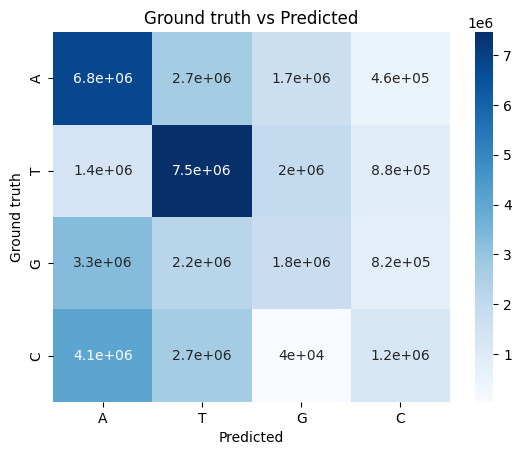

In [11]:
# visualize gt_vs_pred_matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(gt_vs_pred_matrix, annot=True, cmap='Blues', xticklabels=base_pairs, yticklabels=base_pairs)
plt.xlabel('Predicted')
plt.ylabel('Ground truth')
plt.title('Ground truth vs Predicted')
plt.show()

In [12]:
print ("Accurace per base pair:")
for idx, bp in enumerate(base_pairs):
	print (bp, f"{gt_vs_pred_matrix[idx,idx]/sum(gt_vs_pred_matrix[idx,:]):.3f} (genome frequency: {sum(gt_vs_pred_matrix[idx,:])/np.sum(gt_vs_pred_matrix):.3f})")

Accurace per base pair:
A 0.585 (genome frequency: 0.295)
T 0.640 (genome frequency: 0.296)
G 0.217 (genome frequency: 0.205)
C 0.154 (genome frequency: 0.204)


In [18]:
0.6*0.5

0.3

In [ ]:
gt_vs_pred_matrix[1,1]/sum(gt_vs_pred_matrix[0,:])

In [6]:
ground_truth_dict["A"]+ground_truth_dict["T"]

1842275

In [12]:
import pyBigWig


In [25]:
import pandas as pd
pd.Series(pred_bp).value_counts()

84    1863
65    1829
71     431
67     336
dtype: int64

In [29]:
chr(67)

'C'

In [12]:
refs = [f for f in fasta.references if f.startswith('chr21:')]
refs[:30]

['chr21:5010000-5166246',
 'chr21:5216246-5393558',
 'chr21:5443558-5449012',
 'chr21:5499012-5627596',
 'chr21:5677596-5796009',
 'chr21:5846009-5916593',
 'chr21:5966593-6161371',
 'chr21:6211371-6377258',
 'chr21:6427258-6580181',
 'chr21:6630181-6739085',
 'chr21:6789085-6934219',
 'chr21:6984219-7149527',
 'chr21:7199527-7327865',
 'chr21:7377865-7500890',
 'chr21:7550890-7693700',
 'chr21:7743700-7865746',
 'chr21:7915746-8049839',
 'chr21:8099839-8217206',
 'chr21:8217207-8260971',
 'chr21:8310971-8472360',
 'chr21:8522360-8706715',
 'chr21:8756715-8886604',
 'chr21:8986604-9196087',
 'chr21:9246087-9377143',
 'chr21:9527143-10169868',
 'chr21:10269868-10274327',
 'chr21:10324327-10814560',
 'chr21:10864560-10887097',
 'chr21:10887197-10975219',
 'chr21:10975319-11029452']

In [ ]:
chr21:10324327-10814560

In [30]:
10356327-10340327

16000

In [31]:
10324327-10356327

-32000